In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

## Clean numeric data
 Remove commas, spaces, and converting to float

In [11]:
def clean_numeric_data(value):
    if pd.isna(value) or value == '':
        return np.nan
    cleaned = str(value).replace(',', '').replace(' ', '').strip()
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

## 1. Load and preprocess data

In [12]:
df = pd.read_csv('company_revenue.csv')
print(f"Data shape: {df.shape}")

# Clean numeric data first
numeric_columns = ['revenue_q1', 'revenue_q2', 'growth_rate', 'predicted_sales']
for col in numeric_columns:
    df[col] = df[col].apply(clean_numeric_data)

# Remove rows with missing values
df_clean = df.dropna(subset=numeric_columns)
print(f"Cleaned data shape: {df_clean.shape}")
    

Data shape: (100, 5)
Cleaned data shape: (100, 5)


## 2. Feature Selection

In [13]:
feature_columns = ['revenue_q1', 'revenue_q2', 'growth_rate']
target_column = 'predicted_sales'
X = df[feature_columns]
y = df[target_column]

## 3. Data Splitting

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Data Scaling

In [15]:
# Scale features using StandardScaler (z-score normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Also scale the target variable for better training
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

## 5. Model Training

### Linear Regression

In [ ]:
model_results = {}

lr_model = LinearRegression()

# Train final model
lr_model.fit(X_train_scaled, y_train_scaled)

# Make predictions
y_pred_test_scaled = lr_model.predict(X_test_scaled)

# Convert back to original scale
y_pred_test_orig = target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_orig))
test_r2 = r2_score(y_test, y_pred_test_orig)
test_mae = mean_absolute_error(y_test, y_pred_test_orig)

print("\nLinear Regression Performance before tuning (on original scale):")
print(f"Test RMSE: {test_rmse:,.0f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:,.0f}")


Linear Regression Performance before tuning (on original scale):
Test RMSE: 10,423,020
Test R²: 0.9426
Test MAE: 8,443,818


In [44]:
#Store best model result for model comparison
model_results['Linear Regression'] = {
    'test_rmse': test_rmse,
    'test_r2': test_r2,
    'test_mae': test_mae
}

### Random Forest Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


rf_model = RandomForestRegressor(random_state=42)

# Train final model
rf_model.fit(X_train_scaled, y_train_scaled)

# Make predictions
y_pred_test_scaled = rf_model.predict(X_test_scaled)

# Convert back to original scale
y_pred_test_orig = target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_orig))
test_r2 = r2_score(y_test, y_pred_test_orig)
test_mae = mean_absolute_error(y_test, y_pred_test_orig)

print("\nRandom Forest Regressor Performance before tuning (on original scale):")
print(f"Test RMSE: {test_rmse:,.0f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:,.0f}")

# Define parameter distributions for Random Forest
rf_param_distributions = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'max_samples': [0.7, 0.8, 0.9, None]
}

# Run RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    rf_model, 
    rf_param_distributions, 
    n_iter=100,  # Number of parameter combinations to try
    cv=5, 
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train_scaled, y_train_scaled)

print(f"\nBest parameters: {random_search_rf.best_params_}")
print(f"Best CV score: {random_search_rf.best_score_:.6f}")

# Get best model
rf_best = random_search_rf.best_estimator_

# Make predictions
y_pred_test_scaled = rf_best.predict(X_test_scaled)

# Convert back to original scale
y_pred_test_orig_tuned = target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

# Calculate metrics on original scale
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_orig_tuned))
test_r2_tuned = r2_score(y_test, y_pred_test_orig_tuned)
test_mae_tuned = mean_absolute_error(y_test, y_pred_test_orig_tuned)

print("\nRandom Forest Regressor Performance after tuning (on original scale):")
print(f"Test RMSE: {test_rmse_tuned:,.0f}")
print(f"Test R²: {test_r2_tuned:.4f}")
print(f"Test MAE: {test_mae_tuned:,.0f}")



Random Forest Regressor Performance before tuning (on original scale):
Test RMSE: 13,006,843
Test R²: 0.9107
Test MAE: 6,635,256

Best parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_features': None, 'max_depth': None, 'bootstrap': True}
Best CV score: 0.661195

Random Forest Regressor Performance after tuning (on original scale):
Test RMSE: 19,632,954
Test R²: 0.7965
Test MAE: 8,175,107


In [46]:
#Store best model result for model comparison
model_results['Random Forest Regressor'] = {
    'test_rmse': test_rmse,
    'test_r2': test_r2,
    'test_mae': test_mae
}


### XGBoost Regressor

In [47]:
xgb_model = XGBRegressor(random_state=42)

# Train the baseline model on  training data
xgb_model.fit(X_train_scaled, y_train_scaled)

# Make predictions and calculate final performance
y_pred_test = xgb_model.predict(X_test_scaled)

# Convert predictions back to original scale for evaluation
y_pred_test_orig = target_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

# Calculate metrics on original scale
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_orig))
test_r2 = r2_score(y_test, y_pred_test_orig)
test_mae = mean_absolute_error(y_test, y_pred_test_orig)

print("\nXGBoost Regressor Performance before tuning (on original scale):")
print(f"Test RMSE: {test_rmse:,.0f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:,.0f}")

# Define parameter search space
param_distributions = {
    'n_estimators': [50, 75, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# Run RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    xgb_model, 
    param_distributions, 
    n_iter=100,  # Number of parameter combinations to try
    cv=5, 
    scoring='r2',
    random_state=42,
    n_jobs=-1  
)

random_search_xgb.fit(X_train_scaled, y_train_scaled)
print(f"\nBest parameters: {random_search_xgb.best_params_}")
print(f"Best CV score: {random_search_xgb.best_score_}")

xgb_best = random_search_xgb.best_estimator_

# Make predictions and calculate final performance
y_pred_test_tuned = xgb_best.predict(X_test_scaled)
y_pred_test_orig_tuned = target_scaler.inverse_transform(y_pred_test_tuned.reshape(-1, 1)).flatten()

# Calculate metrics on original scale
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_orig_tuned))
test_r2_tuned = r2_score(y_test, y_pred_test_orig_tuned)
test_mae_tuned = mean_absolute_error(y_test, y_pred_test_orig_tuned)

print("\nXGBoost Regressor Performance after tuning (on original scale):")
print(f"Test RMSE: {test_rmse_tuned:,.0f}")
print(f"Test R²: {test_r2_tuned:.4f}")
print(f"Test MAE: {test_mae_tuned:,.0f}")
    


XGBoost Regressor Performance before tuning (on original scale):
Test RMSE: 9,883,928
Test R²: 0.9484
Test MAE: 6,301,949

Best parameters: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV score: 0.6184247284280888

XGBoost Regressor Performance after tuning (on original scale):
Test RMSE: 10,852,664
Test R²: 0.9378
Test MAE: 9,063,556


In [48]:
#Store best model result for model comparison
model_results['XGBoost Regressor'] = {
    'test_rmse': test_rmse,
    'test_r2': test_r2,
    'test_mae': test_mae
}


## 6. Model Comparison


Performance Comparison:
                  Model Test R²  Test RMSE  Test MAE
      Linear Regression  0.9426 10,423,020 8,443,818
Random Forest Regressor  0.9107 13,006,843 6,635,256
      XGBoost Regressor  0.9484  9,883,928 6,301,949

--------------------------------------------------
BEST MODEL ANALYSIS:
--------------------------------------------------
🏆 Best Test R²: XGBoost Regressor (0.9484)
🎯 Best Test RMSE: XGBoost Regressor (9,883,928)
📊 Best Test MAE: XGBoost Regressor (6,301,949)


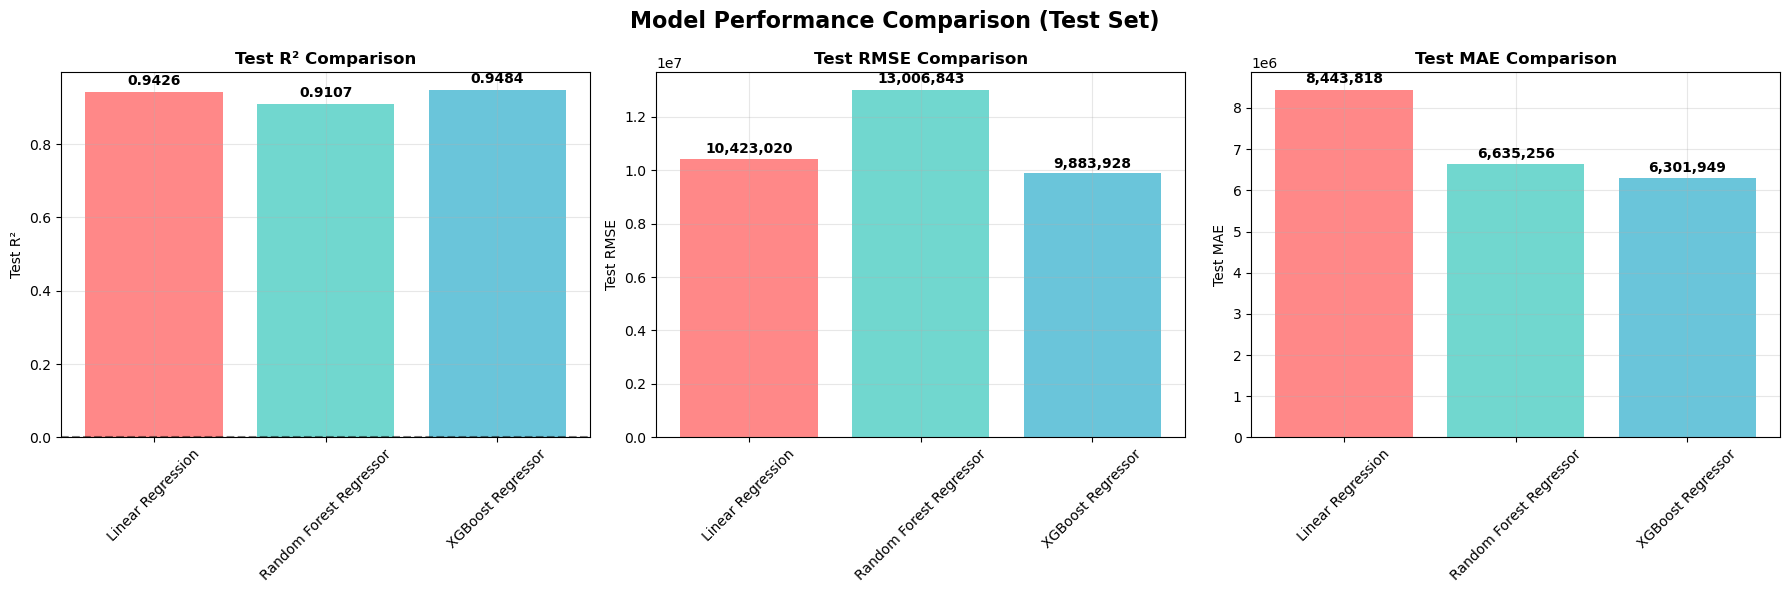

In [57]:
 # Create comparison table
comparison_data = []
for model_name, results in model_results.items():
    comparison_data.append({
        'Model': model_name,
        'Test R²': f"{results['test_r2']:.4f}",
        'Test RMSE': f"{results['test_rmse']:,.0f}",
        'Test MAE': f"{results['test_mae']:,.0f}",
    })

# Display comparison table
comparison_df = pd.DataFrame(comparison_data)
print("\nPerformance Comparison:")
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "-"*50)
print("BEST MODEL ANALYSIS:")
print("-"*50)

# Best Test R²
best_r2_model = max(model_results.items(), key=lambda x: x[1]['test_r2'])
print(f"🏆 Best Test R²: {best_r2_model[0]} ({best_r2_model[1]['test_r2']:.4f})")

# Best Test RMSE
best_rmse_model = min(model_results.items(), key=lambda x: x[1]['test_rmse'])
print(f"🎯 Best Test RMSE: {best_rmse_model[0]} ({best_rmse_model[1]['test_rmse']:,.0f})")

# Best Test MAE
best_mae_model = min(model_results.items(), key=lambda x: x[1]['test_mae'])
print(f"📊 Best Test MAE: {best_mae_model[0]} ({best_mae_model[1]['test_mae']:,.0f})")

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison (Test Set)', fontsize=16, fontweight='bold')

# Define the metrics we want to plot
metrics = ['Test R²', 'Test RMSE', 'Test MAE']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, metric in enumerate(metrics):
    # Extract values and convert strings to numbers
    values = []
    for row in comparison_data:
        value = row[metric]
        if isinstance(value, str):
            # Remove commas and convert to float
            if metric == 'Test R²':
                values.append(float(value))
            else:
                # For RMSE and MAE, remove commas and convert
                values.append(float(value.replace(',', '')))
        else:
            values.append(value)
    
    model_names = [row['Model'] for row in comparison_data]
    
    bars = axes[i].bar(model_names, values, color=colors, alpha=0.8)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{value:,.0f}' if metric != 'Test R²' else f'{value:.4f}', 
                    ha='center', va='bottom', fontweight='bold')
    
    # For R², add horizontal line at 0
    if metric == 'Test R²':
        axes[i].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Rotate x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Persistence

In [60]:
import joblib
joblib.dump(xgb_model, 'xgboost_sales_model.pkl')
joblib.dump(scaler, 'xgboost_sales_scaler.pkl')
joblib.dump(target_scaler, 'xgboost_sales_target_scaler.pkl')    

['xgboost_sales_target_scaler.pkl']

## 7. Prediction on new data

In [65]:
model = joblib.load('xgboost_sales_model.pkl')
scaler = joblib.load('xgboost_sales_scaler.pkl')
target_scaler = joblib.load('xgboost_sales_target_scaler.pkl')

# Validate input ranges
revenue_q1 = 3000000
revenue_q2 = 1234567
growth_rate = (revenue_q2 - revenue_q1) / revenue_q1

# Prepare features for prediction
X = np.array([[revenue_q1, revenue_q2, growth_rate]])

# Apply StandardScaler transformation (same as training)
X_scaled = scaler.transform(X)

# Make prediction on scaled data
prediction_scaled = model.predict(X_scaled)

# Convert prediction back to original scale using target_scaler
prediction = target_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0, 0]
prediction = float(prediction)  # Convert numpy float32 to Python float
print('Predicted Sales:', prediction)

Predicted Sales: 1095903.25
